In [2]:
import sys
print(sys.executable)

c:\Users\yogit\OneDrive\Desktop\Pneumonia Detection\venv\Scripts\python.exe


In [3]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import (
    confusion_matrix,
    classification_report
)

import seaborn as sns
from PIL import Image

from lime import lime_image
from skimage.segmentation import mark_boundaries

c:\Users\yogit\OneDrive\Desktop\Pneumonia Detection\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

In [5]:
train_path = 'dataset/chest_xray/train'
val_path = 'dataset/chest_xray/val'
test_path = 'dataset/chest_xray/test'

In [6]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

In [8]:
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(300, 300),
    batch_size=32,
    class_mode='binary'
)

validation_generator = test_datagen.flow_from_directory(
    val_path,
    target_size=(300, 300),
    batch_size=32,
    class_mode='binary'
)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=(300, 300),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


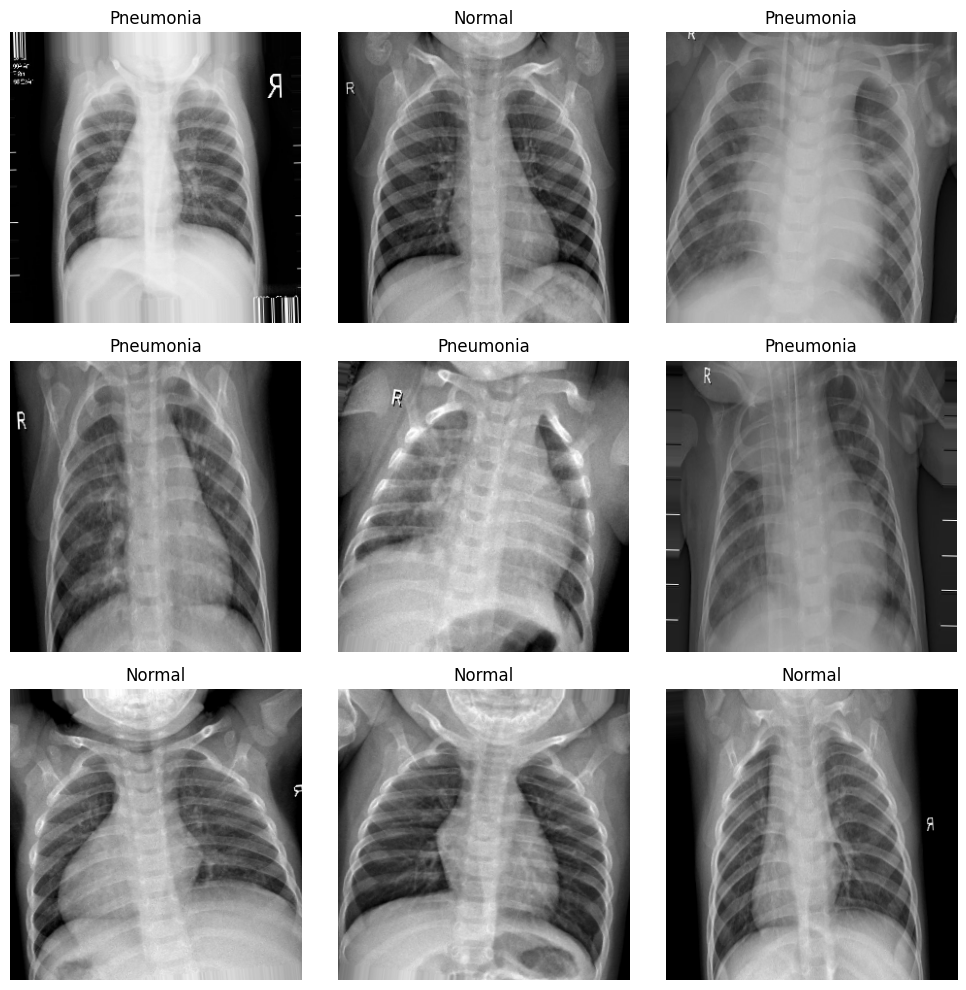

In [9]:
images, labels = next(train_generator)

plt.figure(figsize=(10, 10))

for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images[i])
    plt.title("Pneumonia" if labels[i] == 1 else "Normal")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [10]:
model = Sequential([

    Conv2D(
        16,
        (3, 3),
        activation='relu',
        input_shape=(300, 300, 3)
    ),
    MaxPooling2D(2, 2),

    Conv2D(
        32,
        (3, 3),
        activation='relu'
    ),
    MaxPooling2D(2, 2),

    Conv2D(
        64,
        (3, 3),
        activation='relu'
    ),
    MaxPooling2D(2, 2),

    Conv2D(
        128,
        (3, 3),
        activation='relu'
    ),
    MaxPooling2D(2, 2),

    Flatten(),

    Dense(
        256,
        activation='relu'
    ),

    Dropout(0.5),

    Dense(
        1,
        activation='sigmoid'
    )
])

c:\Users\yogit\OneDrive\Desktop\Pneumonia Detection\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 298, 298, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 149, 149, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 147, 147, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 73, 73, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 71, 71, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 35, 35, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 33, 33, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,486,561 (32.37 MB)

 Trainable params: 8,486,561 (32.37 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [13]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [15]:
history = model.fit(
    train_generator,
    epochs=20,
    validation_data=validation_generator,
    callbacks=[early_stop]
)

Epoch 1/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 458s 3s/step - accuracy: 0.8468 - loss: 0.3482 - val_accuracy: 0.7500 - val_loss: 0.3991
Epoch 2/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 412s 3s/step - accuracy: 0.8997 - loss: 0.2502 - val_accuracy: 0.8750 - val_loss: 0.3124
Epoch 3/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 372s 2s/step - accuracy: 0.9181 - loss: 0.2061 - val_accuracy: 0.8125 - val_loss: 0.4831
Epoch 4/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 348s 2s/step - accuracy: 0.9285 - loss: 0.1814 - val_accuracy: 0.6250 - val_loss: 0.9673
Epoch 5/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 288s 2s/step - accuracy: 0.9316 - loss: 0.1752 - val_accuracy: 0.6250 - val_loss: 0.9081


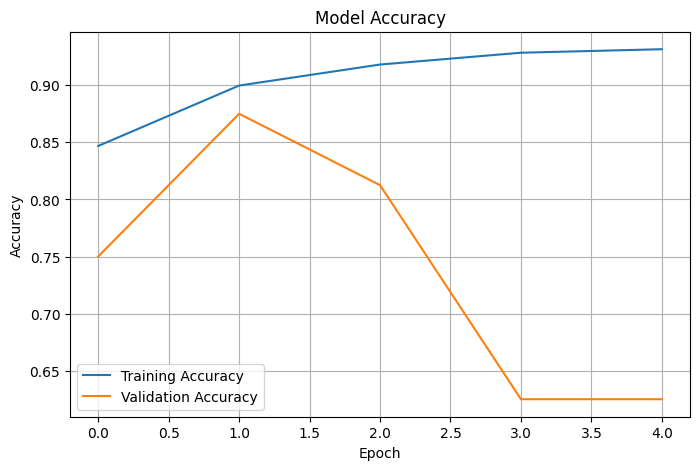

In [16]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend()
plt.grid(True)

plt.show()

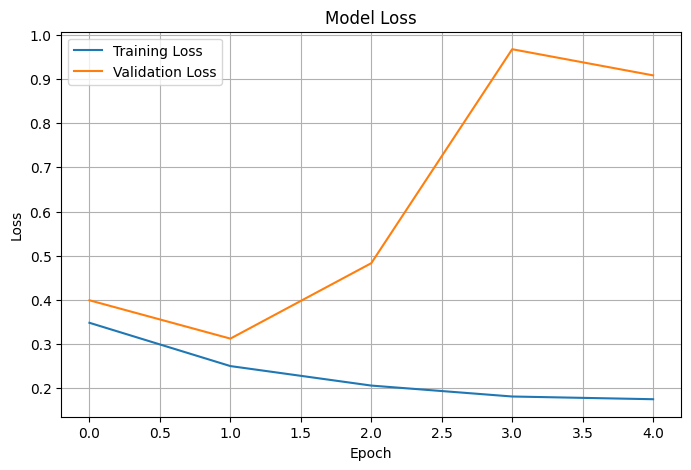

In [17]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend()
plt.grid(True)

plt.show()

In [18]:
test_loss, test_accuracy = model.evaluate(test_generator)

print(f"\nTest Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

20/20 ━━━━━━━━━━━━━━━━━━━━ 19s 925ms/step - accuracy: 0.8878 - loss: 0.2762

Test Accuracy: 0.8878
Test Loss: 0.2762


In [19]:
predictions = model.predict(test_generator)

predicted_classes = (
    predictions > 0.5
).astype(int).flatten()

20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 508ms/step


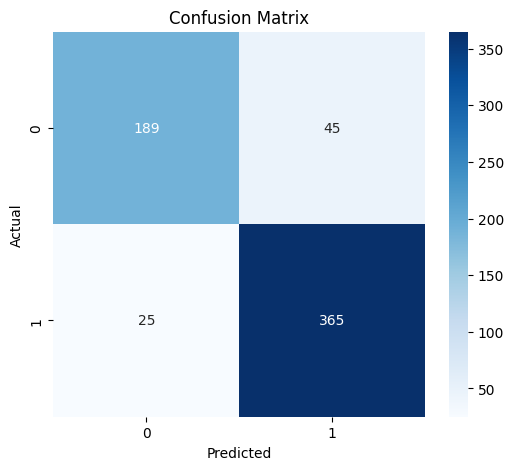

In [20]:
cm = confusion_matrix(
    test_generator.classes,
    predicted_classes
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

In [21]:
print("\nClassification Report:\n")

print(classification_report(
    test_generator.classes,
    predicted_classes,
    target_names=['Normal', 'Pneumonia']
))


Classification Report:

              precision    recall  f1-score   support

      Normal       0.88      0.81      0.84       234
   Pneumonia       0.89      0.94      0.91       390

    accuracy                           0.89       624
   macro avg       0.89      0.87      0.88       624
weighted avg       0.89      0.89      0.89       624



In [22]:
model.save('trained.h5')

print("\nModel saved successfully as trained.h5")


Model saved successfully as trained.h5


In [23]:
loaded_model = tf.keras.models.load_model('trained.h5')

print("\nModel loaded successfully.")


Model loaded successfully.


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 671ms/step


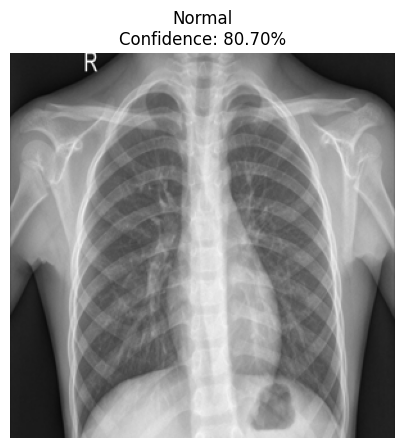

In [25]:
image_path = 'dataset/chest_xray/test/NORMAL/IM-0001-0001.jpeg'   # CHANGE THIS

img = Image.open(image_path).convert('RGB')
img = img.resize((300, 300))

img_array = np.array(img) / 255.0

img_batch = np.expand_dims(img_array, axis=0)

prediction = loaded_model.predict(img_batch)[0][0]

predicted_class = (
    "Pneumonia"
    if prediction > 0.5
    else "Normal"
)

confidence = (
    prediction
    if predicted_class == "Pneumonia"
    else 1 - prediction
)

plt.figure(figsize=(5, 5))
plt.imshow(img)
plt.title(
    f"{predicted_class}\nConfidence: {confidence*100:.2f}%"
)
plt.axis("off")

plt.show()

In [26]:
def lime_predict(images):

    images = np.array(images)

    preds = loaded_model.predict(images)

    return np.concatenate(
        [1 - preds, preds],
        axis=1
    )

In [27]:
explainer = lime_image.LimeImageExplainer()

explanation = explainer.explain_instance(
    img_array,
    lime_predict,
    top_labels=1,
    hide_color=0,
    num_samples=200
)

temp, mask = explanation.get_image_and_mask(
    explanation.top_labels[0],
    positive_only=True,
    num_features=5,
    hide_rest=False
)

lime_result = mark_boundaries(temp, mask)

  0%|          | 0/200 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 510ms/step


  5%|▌         | 10/200 [00:00<00:13, 13.63it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step


 10%|█         | 20/200 [00:01<00:08, 20.88it/s]

...

 92%|█████████▎| 185/200 [00:06<00:00, 34.12it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step


 95%|█████████▌| 190/200 [00:06<00:00, 29.69it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step


100%|██████████| 200/200 [00:06<00:00, 30.15it/s]


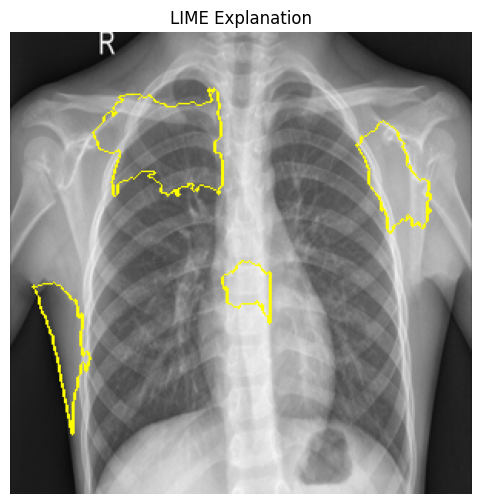

In [28]:
plt.figure(figsize=(6, 6))

plt.imshow(lime_result)

plt.title("LIME Explanation")

plt.axis("off")

plt.show()